In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

from architectures.nn_build import build_mlp
from architectures.gating import GatingNetwork
from architectures.expert_pool import ExpertPool
from architectures.moe_pricer import MoEPricer

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
df = pd.read_csv("../data/vanilla_convertibles_data_enhanced.csv")
df = df.dropna(subset=["price_normalized"])

X = df.drop(columns=["price_convertible", "price_normalized", "redemption"])
y = df[["price_normalized"]]

feature_cols = list(X.columns)
print(f"Features ({len(feature_cols)}): {feature_cols}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

In [ ]:
# Load scalers and baseline checkpoint
import pickle
from sklearn.preprocessing._data import BOUNDS_THRESHOLD
from scipy.stats import norm

with open("../models/scaler_X.pkl", "rb") as f:
    scaler_X = pickle.load(f)
with open("../models/scaler_y.pkl", "rb") as f:
    scaler_y = pickle.load(f)
checkpoint = torch.load("../models/baseline_fnn.pt", map_location="cpu")

X_train_sc = scaler_X.transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.transform(y_train)
y_val_sc   = scaler_y.transform(y_val)

_lower = norm.ppf(BOUNDS_THRESHOLD)
_upper = norm.ppf(1 - BOUNDS_THRESHOLD)
X_train_sc = np.clip(X_train_sc, _lower, _upper)
X_val_sc   = np.clip(X_val_sc, _lower, _upper)
X_test_sc  = np.clip(X_test_sc, _lower, _upper)
y_train_sc = np.clip(y_train_sc, _lower, _upper)
y_val_sc   = np.clip(y_val_sc, _lower, _upper)

In [5]:
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train_sc, dtype=torch.float32).squeeze()
X_val_t = torch.tensor(X_val_sc, dtype=torch.float32)
y_val_t = torch.tensor(y_val_sc, dtype=torch.float32).squeeze()
X_test_t = torch.tensor(X_test_sc, dtype=torch.float32)

# Raw (unscaled) tensors for gating — boundaries need original scale
X_train_raw_t = torch.tensor(X_train.values, dtype=torch.float32)
X_val_raw_t = torch.tensor(X_val.values, dtype=torch.float32)
X_test_raw_t = torch.tensor(X_test.values, dtype=torch.float32)

In [6]:
INPUT_DIM = X_train_t.shape[1]
OUTPUT_DIM = 1

M, N = 2, 2

# Match baseline best architecture from fnn_baseline.ipynb
BASELINE_DEPTH = 5
BASELINE_WIDTH = 768

# Expert architecture
HIDDEN_DIMS = [768, 768, 768]
ACTIVATION = "leaky_relu"
BATCH_NORM = True

MONEYNESS_COL = feature_cols.index("log_moneyness")
MATURITY_COL = feature_cols.index("maturity_years")

BATCH_SIZE = 1024
LR = 1e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 200
PATIENCE = 10

print(f"Device: {device} | Input: {INPUT_DIM} | Output: {OUTPUT_DIM}")
print(f"Grid: {M}x{N} = {M*N} experts")
print(f"Expert arch: {HIDDEN_DIMS}, {ACTIVATION}, batch_norm={BATCH_NORM}")
print(f"Moneyness col: {MONEYNESS_COL} ({feature_cols[MONEYNESS_COL]})")
print(f"Maturity col:  {MATURITY_COL} ({feature_cols[MATURITY_COL]})")

Device: cpu | Input: 24 | Output: 1
Grid: 2x2 = 4 experts
Expert arch: [768, 768, 768], leaky_relu, batch_norm=True
Moneyness col: 10 (log_moneyness)
Maturity col:  7 (maturity_years)


## FNN Baseline Residuals for Variance-Optimal Partitioning

Train the baseline FNN (depth=5, width=768 from `fnn_baseline.ipynb`) and compute
per-sample residuals. These residuals are passed to `from_data(strategy="variance")`
so that boundaries are placed where the baseline error varies most.

In [7]:
# Build and load pre-trained baseline model from checkpoint
baseline_model = build_mlp(
    checkpoint["input_dim"],
    checkpoint["output_dim"],
    checkpoint["depth"],
    checkpoint["width"],
    batch_norm=True,
).to(device)
baseline_model.load_state_dict(checkpoint["model_state_dict"])
baseline_model.eval()
print("Loaded baseline_fnn.pt — depth=%d, width=%d" % (checkpoint["depth"], checkpoint["width"]))

Loaded baseline_fnn.pt — depth=5, width=768


In [8]:
all_preds = []
with torch.no_grad():
    for i in range(0, len(X_train_t), BATCH_SIZE):
        x_sc = X_train_t[i:i+BATCH_SIZE].to(device)
        pred = baseline_model(x_sc).squeeze(-1)
        all_preds.append(pred.cpu())

residuals_train = torch.cat(all_preds) - y_train_t

print(f"Residuals shape: {residuals_train.shape}")
print(f"Residual stats: mean={residuals_train.mean():.6f}, std={residuals_train.std():.6f}")
print(f"  min={residuals_train.min():.6f}, max={residuals_train.max():.6f}")
print(f"  |residual| mean={residuals_train.abs().mean():.6f}")

Residuals shape: torch.Size([600000])
Residual stats: mean=-0.001500, std=0.008321
  min=-0.836429, max=0.205824
  |residual| mean=0.006675


## Bandwidth Search with Variance-Optimal Gating

Sweep `kernel_bandwidth` using variance-optimal DP boundaries computed on the
baseline residuals. Gating routes on raw (unscaled) `log_moneyness` and `maturity_years`,
while experts receive scaled features.

In [9]:
def train_epoch(pricer, dataloader, optimizers, device):
    """One epoch: gating on raw features, experts on scaled features."""
    pricer.expert_pool.train()
    M, N = pricer.gating.M, pricer.gating.N
    total_loss = 0.0
    n_batches = 0

    for x_sc, x_raw, y_batch in dataloader:
        x_sc = x_sc.to(device)
        x_raw = x_raw.to(device)
        y_flat = y_batch.to(device).view(-1)

        weights = pricer.gating.get_training_weights(x_raw)

        batch_loss = 0.0
        for i in range(M):
            for j in range(N):
                flat_idx = i * N + j
                opt = optimizers[flat_idx]
                expert = pricer.expert_pool.experts[flat_idx]

                opt.zero_grad()
                pred = expert(x_sc).squeeze(-1)
                w = weights[:, i, j]
                loss = (w * (pred - y_flat).pow(2)).sum() / w.sum()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(expert.parameters(), max_norm=1.0)
                opt.step()
                batch_loss += loss.item()

        total_loss += batch_loss / (M * N)
        n_batches += 1

    return total_loss / max(n_batches, 1)


def evaluate(pricer, dataloader, device):
    """Hard-routed MSE: gating on raw, experts on scaled."""
    pricer.expert_pool.eval()
    total_se = 0.0
    total_n = 0
    with torch.no_grad():
        for x_sc, x_raw, y_batch in dataloader:
            x_sc = x_sc.to(device)
            x_raw = x_raw.to(device)
            y_flat = y_batch.to(device).view(-1)
            m_bins, t_bins = pricer.gating.route(x_raw)
            pred = pricer.expert_pool.forward_routed(x_sc, m_bins, t_bins).squeeze(-1)
            total_se += (pred - y_flat).pow(2).sum().item()
            total_n += len(y_flat)
    return total_se / total_n


def train_moe(pricer, train_loader, val_loader, device, lr, wd, epochs, patience, seed):
    """Full training run with early stopping. Returns best val loss, best state dict, and curves."""
    torch.manual_seed(seed)

    optimizers = [
        torch.optim.AdamW(expert.parameters(), lr=lr, weight_decay=wd)
        for expert in pricer.expert_pool.experts
    ]
    schedulers = [
        torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
        for opt in optimizers
    ]

    train_losses, val_losses = [], []
    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(1, epochs + 1):
        t_loss = train_epoch(pricer, train_loader, optimizers, device)
        v_loss = evaluate(pricer, val_loader, device)

        train_losses.append(t_loss)
        val_losses.append(v_loss)

        for sched in schedulers:
            sched.step(v_loss)

        if v_loss < best_val:
            best_val = v_loss
            best_state = {k: v.cpu().clone() for k, v in pricer.expert_pool.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0 or wait == 0:
            print(f"  Epoch {epoch:3d} | Train: {t_loss:.6f} | Val: {v_loss:.6f} | Wait: {wait}")

        if wait >= patience:
            print(f"  Early stop at epoch {epoch}")
            break

    print(f"  Best Val Loss: {best_val:.6f}")
    return best_val, best_state, train_losses, val_losses

In [10]:
BANDWIDTHS = [0.25, 0.5, 1.0, 2.0, 4.0]
print(f"Bandwidth sweep: {BANDWIDTHS}")
print(f"Strategy: variance-optimal (y = baseline residuals)")

train_ds = TensorDataset(X_train_t, X_train_raw_t, y_train_t)
val_ds = TensorDataset(X_val_t, X_val_raw_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

bw_results = []

for bw in BANDWIDTHS:
    print(f"\n{'='*50}")
    print(f"Bandwidth = {bw}")
    print(f"{'='*50}")

    gating = GatingNetwork.from_data(
        X_train_raw_t,
        n_moneyness_bins=M,
        n_maturity_bins=N,
        strategy="variance",
        kernel_bandwidth=bw,
        moneyness_col_idx=MONEYNESS_COL,
        maturity_col_idx=MATURITY_COL,
        y=residuals_train,
    )

    counts = gating.get_bin_counts(X_train_raw_t)
    print(f"  Bin counts: {counts.tolist()}")

    torch.manual_seed(SEED)
    pool = ExpertPool(
        n_moneyness_bins=M,
        n_maturity_bins=N,
        input_dim=INPUT_DIM,
        output_dim=OUTPUT_DIM,
        default_hidden_dims=HIDDEN_DIMS,
        default_activation=ACTIVATION,
        batch_norm=BATCH_NORM,
    ).to(device)

    pricer = MoEPricer(gating, pool)

    best_val, best_state, t_losses, v_losses = train_moe(
        pricer, train_loader, val_loader, device,
        lr=LR, wd=WEIGHT_DECAY, epochs=EPOCHS, patience=PATIENCE,
        seed=SEED,
    )

    bw_results.append({
        "bandwidth": bw,
        "best_val_loss": best_val,
        "best_state": best_state,
        "gating": gating,
        "train_losses": t_losses,
        "val_losses": v_losses,
    })

Bandwidth sweep: [0.25, 0.5, 1.0, 2.0, 4.0]
Strategy: variance-optimal (y = baseline residuals)

Bandwidth = 0.25
  Bin counts: [[99636, 40113], [327655, 132596]]
  Epoch   1 | Train: 0.042227 | Val: 0.007755 | Wait: 0
  Epoch   2 | Train: 0.006005 | Val: 0.002086 | Wait: 0
  Epoch   3 | Train: 0.004892 | Val: 0.001549 | Wait: 0
  Epoch   4 | Train: 0.004567 | Val: 0.001250 | Wait: 0
  Epoch   5 | Train: 0.003705 | Val: 0.000924 | Wait: 0
  Epoch   8 | Train: 0.003463 | Val: 0.000748 | Wait: 0
  Epoch   9 | Train: 0.003525 | Val: 0.000521 | Wait: 0
  Epoch  10 | Train: 0.003511 | Val: 0.001082 | Wait: 1
  Epoch  12 | Train: 0.003194 | Val: 0.000429 | Wait: 0
  Epoch  16 | Train: 0.002937 | Val: 0.000374 | Wait: 0
  Epoch  18 | Train: 0.002902 | Val: 0.000359 | Wait: 0
  Epoch  20 | Train: 0.002440 | Val: 0.003518 | Wait: 2
  Epoch  25 | Train: 0.002199 | Val: 0.000310 | Wait: 0
  Epoch  26 | Train: 0.001916 | Val: 0.000273 | Wait: 0
  Epoch  27 | Train: 0.001995 | Val: 0.000227 | Wait:

In [11]:
bw_df = pd.DataFrame([(r["bandwidth"], r["best_val_loss"]) for r in bw_results],
                      columns=["bandwidth", "best_val_loss"])
print(bw_df.to_string(index=False))

best_bw = bw_df.loc[bw_df["best_val_loss"].idxmin()]
print(f"\nBest bandwidth: {best_bw['bandwidth']} with val loss: {best_bw['best_val_loss']:.6f}")

 bandwidth  best_val_loss
      0.25       0.000145
      0.50       0.000054
      1.00       0.000063
      2.00       0.000050
      4.00       0.000053

Best bandwidth: 2.0 with val loss: 0.000050


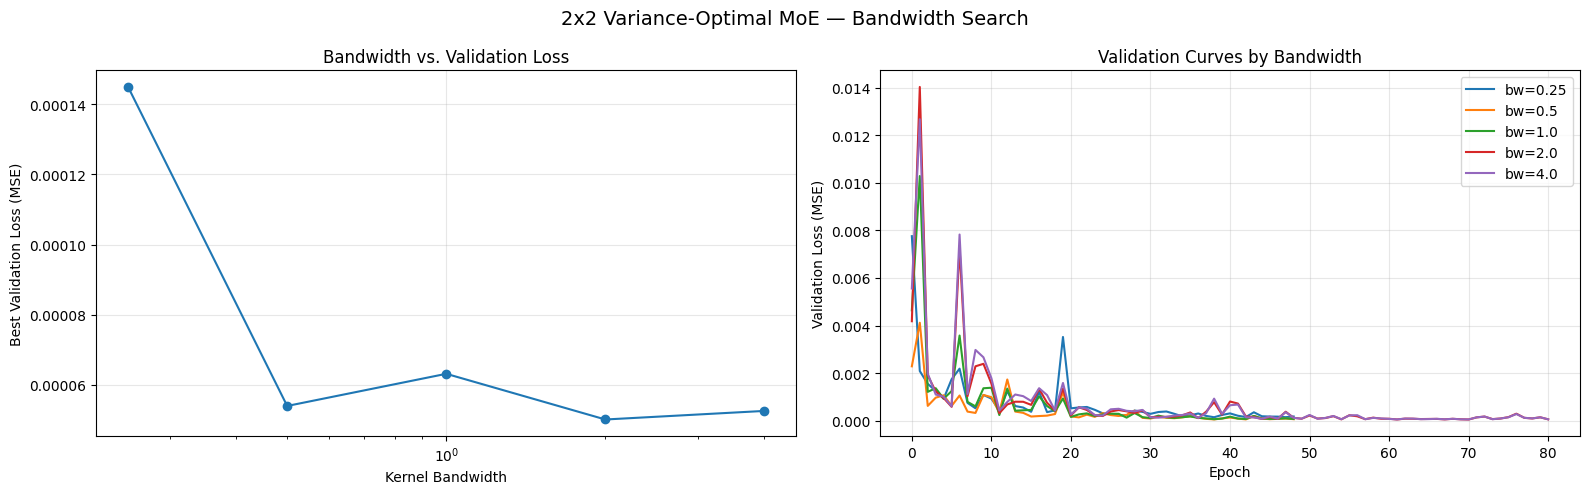

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bandwidth vs val loss
axes[0].plot(bw_df["bandwidth"], bw_df["best_val_loss"], marker="o")
axes[0].set_xlabel("Kernel Bandwidth")
axes[0].set_ylabel("Best Validation Loss (MSE)")
axes[0].set_title("Bandwidth vs. Validation Loss")
axes[0].set_xscale("log")
axes[0].grid(True, alpha=0.3)

# Training curves per bandwidth
for r in bw_results:
    axes[1].plot(r["val_losses"], label=f"bw={r['bandwidth']}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss (MSE)")
axes[1].set_title("Validation Curves by Bandwidth")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"{M}x{N} Variance-Optimal MoE — Bandwidth Search", fontsize=14)
plt.tight_layout()
plt.show()

## Variance-Optimal Boundaries

Report the boundary placements chosen by the variance-optimal DP for the best bandwidth.
Compare these to where quantile boundaries would land.

In [13]:
BEST_BW = best_bw["bandwidth"]

var_gating = GatingNetwork.from_data(
    X_train_raw_t,
    n_moneyness_bins=M,
    n_maturity_bins=N,
    strategy="variance",
    kernel_bandwidth=BEST_BW,
    moneyness_col_idx=MONEYNESS_COL,
    maturity_col_idx=MATURITY_COL,
    y=residuals_train,
)

q_gating = GatingNetwork.from_data(
    X_train_raw_t,
    n_moneyness_bins=M,
    n_maturity_bins=N,
    strategy="quantile",
    kernel_bandwidth=BEST_BW,
    moneyness_col_idx=MONEYNESS_COL,
    maturity_col_idx=MATURITY_COL,
)

print("=== Variance-Optimal Boundaries ===")
print(f"Moneyness boundaries: {var_gating.moneyness_quantiles.tolist()}")
print(f"Maturity boundaries:  {var_gating.maturity_quantiles.tolist()}")
mc, tc = var_gating.get_cell_centers()
print(f"Moneyness centers:    {mc.tolist()}")
print(f"Maturity centers:     {tc.tolist()}")

print("\n=== Quantile Boundaries (for comparison) ===")
print(f"Moneyness boundaries: {q_gating.moneyness_quantiles.tolist()}")
print(f"Maturity boundaries:  {q_gating.maturity_quantiles.tolist()}")
qmc, qtc = q_gating.get_cell_centers()
print(f"Moneyness centers:    {qmc.tolist()}")
print(f"Maturity centers:     {qtc.tolist()}")

print("\n=== Variance-Optimal Bin Counts ===")
var_counts = var_gating.get_bin_counts(X_train_raw_t)
q_counts = q_gating.get_bin_counts(X_train_raw_t)
print(f"Variance-optimal: {var_counts.tolist()}")
print(f"Quantile:         {q_counts.tolist()}")

print("\n=== Variance-Optimal Cell Descriptions ===")
for i in range(M):
    for j in range(N):
        desc = var_gating.describe_cell(i, j)
        print(f"  Cell ({i},{j}): {desc['regime']} | center={desc['center']} | range_m={desc['moneyness_range']} range_t={desc['maturity_range']}")

=== Variance-Optimal Boundaries ===
Moneyness boundaries: [2.335359573364258]
Maturity boundaries:  [9.335874557495117]
Moneyness centers:    [0.03663790225982666, 3.1228275299072266]
Maturity centers:     [5.167937755584717, 9.667930603027344]

=== Quantile Boundaries (for comparison) ===
Moneyness boundaries: [2.4145150184631348]
Maturity boundaries:  [5.505032539367676]
Moneyness centers:    [0.07621562480926514, 3.162405014038086]
Maturity centers:     [3.252516746520996, 7.752510070800781]

=== Variance-Optimal Bin Counts ===
Variance-optimal: [[99636, 40113], [327655, 132596]]
Quantile:         [[72927, 72964], [226886, 227223]]

=== Variance-Optimal Cell Descriptions ===
  Cell (0,0): OTM, short-dated | center=(0.03663790225982666, 5.167937755584717) | range_m=(None, 2.335359573364258) range_t=(None, 9.335874557495117)
  Cell (0,1): OTM, long-dated | center=(0.03663790225982666, 9.667930603027344) | range_m=(None, 2.335359573364258) range_t=(9.335874557495117, None)
  Cell (1,0)

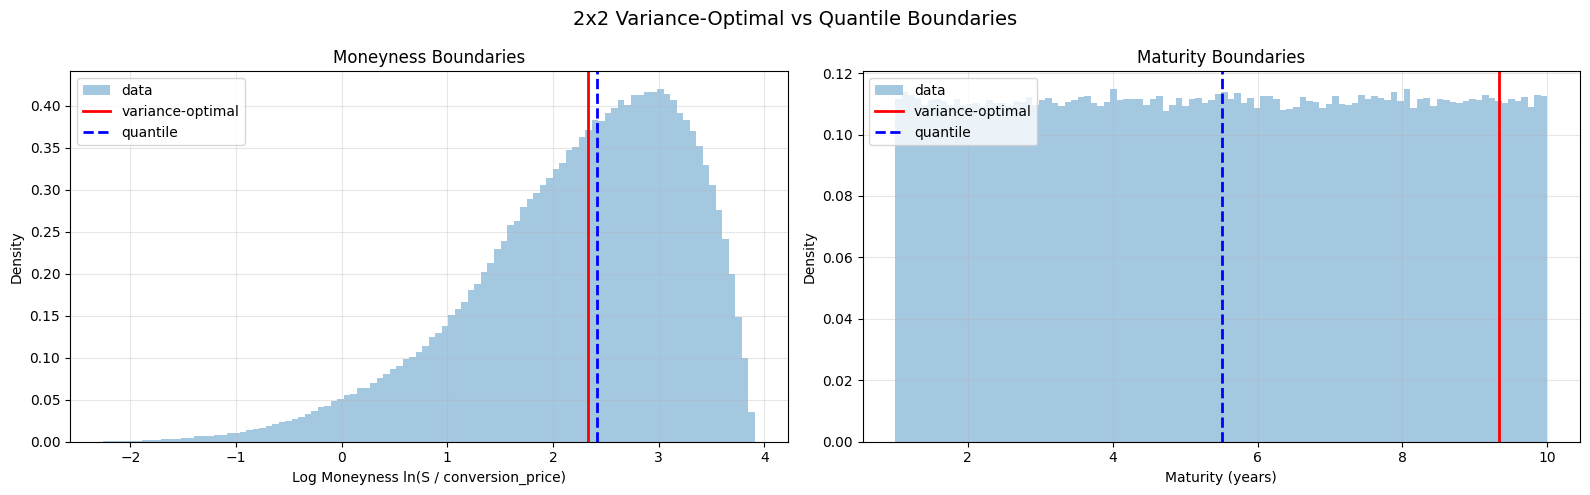

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

m_vals = X_train_raw_t[:, MONEYNESS_COL].numpy()
t_vals = X_train_raw_t[:, MATURITY_COL].numpy()

# Moneyness axis
axes[0].hist(m_vals, bins=100, alpha=0.4, density=True, label="data")
for b in var_gating.moneyness_quantiles.tolist():
    axes[0].axvline(b, color="red", ls="-", lw=2, label="variance-optimal" if b == var_gating.moneyness_quantiles[0].item() else "")
for b in q_gating.moneyness_quantiles.tolist():
    axes[0].axvline(b, color="blue", ls="--", lw=2, label="quantile" if b == q_gating.moneyness_quantiles[0].item() else "")
axes[0].set_xlabel("Log Moneyness ln(S / conversion_price)")
axes[0].set_ylabel("Density")
axes[0].set_title("Moneyness Boundaries")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Maturity axis
axes[1].hist(t_vals, bins=100, alpha=0.4, density=True, label="data")
for b in var_gating.maturity_quantiles.tolist():
    axes[1].axvline(b, color="red", ls="-", lw=2, label="variance-optimal" if b == var_gating.maturity_quantiles[0].item() else "")
for b in q_gating.maturity_quantiles.tolist():
    axes[1].axvline(b, color="blue", ls="--", lw=2, label="quantile" if b == q_gating.maturity_quantiles[0].item() else "")
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("Density")
axes[1].set_title("Maturity Boundaries")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"{M}x{N} Variance-Optimal vs Quantile Boundaries", fontsize=14)
plt.tight_layout()
plt.show()

## Test Set Evaluation

Load best bandwidth model and evaluate on test set.
Convert predictions back to dollar prices via `expm1(price_normalized)`.

In [15]:
BEST_BW = best_bw["bandwidth"]
best_bw_idx = bw_df["best_val_loss"].idxmin()
best_result = bw_results[best_bw_idx]

# Rebuild pool and load best weights
best_pool = ExpertPool(
    n_moneyness_bins=M,
    n_maturity_bins=N,
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    default_hidden_dims=HIDDEN_DIMS,
    default_activation=ACTIVATION,
    batch_norm=BATCH_NORM,
).to(device)
best_pool.load_state_dict(best_result["best_state"])

best_pricer = MoEPricer(best_result["gating"], best_pool)
best_pricer.expert_pool.eval()

print(f"Loaded best model: bandwidth={BEST_BW}")
print(f"Val loss: {best_bw['best_val_loss']:.6f}")

Loaded best model: bandwidth=2.0
Val loss: 0.000050


In [16]:
all_preds_sc = []
with torch.no_grad():
    for i in range(0, len(X_test_t), BATCH_SIZE):
        x_sc = X_test_t[i:i+BATCH_SIZE].to(device)
        x_raw = X_test_raw_t[i:i+BATCH_SIZE].to(device)
        m_bins, t_bins = best_pricer.gating.route(x_raw)
        pred = best_pricer.expert_pool.forward_routed(x_sc, m_bins, t_bins)
        all_preds_sc.append(pred.cpu().numpy())

preds_scaled = np.concatenate(all_preds_sc, axis=0)
preds_norm = scaler_y.inverse_transform(preds_scaled).ravel()
y_true_norm = y_test.values.ravel()

# Convert back to actual price: price_convertible = expm1(price_normalized)
preds_price = np.expm1(preds_norm)
y_true_price = np.expm1(y_true_norm)

mae = np.abs(preds_price - y_true_price).mean()
rmse = np.sqrt(((preds_price - y_true_price) ** 2).mean())

print(f"{'Metric':<10} {'Value':>12}")
print("-" * 24)
print(f"{'MAE':<10} {mae:>12.4f}")
print(f"{'RMSE':<10} {rmse:>12.4f}")

Metric            Value
------------------------
MAE              4.0700
RMSE             5.6219


/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


In [17]:
r2 = r2_score(y_true_price, preds_price)

print(f"{'Metric':<10} {'Value':>12}")
print("-" * 24)
print(f"{'R\u00b2':<10} {r2:>12.6f}")

Metric            Value
------------------------
R²             0.999973


In [18]:
test_features = df.loc[y_test.index]

analysis = pd.DataFrame({
    "price_true": y_true_price,
    "price_pred": preds_price,
    "price_err": np.abs(preds_price - y_true_price),
    "maturity_years": test_features["maturity_years"].values,
    "log_moneyness": test_features["log_moneyness"].values,
    "credit_spread": test_features["credit_spread"].values,
})

# Price regime buckets (dollar terms)
analysis["price_regime"] = pd.cut(analysis["price_true"],
    bins=[0, 200, 500, 1000, 2000, 6000],
    labels=["< $200", "$200-500", "$500-1k", "$1k-2k", "> $2k"])

# Maturity buckets
analysis["maturity"] = pd.cut(analysis["maturity_years"],
    bins=[0, 2, 5, 7, 10],
    labels=["< 2y", "2-5y", "5-7y", "> 7y"])

# Moneyness buckets
analysis["moneyness"] = pd.cut(analysis["log_moneyness"],
    bins=[-3, 0, 1, 2, 3, 5],
    labels=["OTM", "Near ATM", "Mild ITM", "ITM", "Deep ITM"])

# Credit risk buckets (spread in bps)
analysis["credit_risk"] = pd.cut(analysis["credit_spread"],
    bins=[0, 0.03, 0.06, 0.10, 0.15],
    labels=["Low (<300bp)", "Med (300-600bp)", "High (600-1000bp)", "Very High (>1000bp)"])

print("=== Price Error ($) by Price Regime ===")
regime_stats = analysis.groupby("price_regime", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    R2=("price_true", lambda x: r2_score(
        analysis.loc[x.index, "price_true"], analysis.loc[x.index, "price_pred"]))
).reset_index()
print(regime_stats.to_string(index=False))

print("\n=== Price Error ($) by Maturity ===")
mat_stats = analysis.groupby("maturity", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
).reset_index()
print(mat_stats.to_string(index=False))

print("\n=== Price Error ($) by Moneyness ===")
mon_stats = analysis.groupby("moneyness", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
).reset_index()
print(mon_stats.to_string(index=False))

print("\n=== Price Error ($) by Credit Risk ===")
credit_stats = analysis.groupby("credit_risk", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    R2=("price_true", lambda x: r2_score(
        analysis.loc[x.index, "price_true"], analysis.loc[x.index, "price_pred"]))
).reset_index()
print(credit_stats.to_string(index=False))

=== Price Error ($) by Price Regime ===
price_regime  count      MAE     RMSE       R2
      < $200  19660 1.150387 1.580982 0.998493
    $200-500  40147 1.940329 2.625431 0.999084
     $500-1k  54529 2.896182 3.859463 0.999281
      $1k-2k  69424 4.567472 5.942623 0.999572
       > $2k  66240 6.672317 8.067794 0.999863

=== Price Error ($) by Maturity ===
maturity  count      MAE     RMSE
    < 2y  27967 3.904822 5.435369
    2-5y  83425 3.799335 5.232638
    5-7y  55377 3.933193 5.399270
    > 7y  83231 4.487909 6.177772

=== Price Error ($) by Moneyness ===
moneyness  count      MAE     RMSE
      OTM   7786 0.986957 1.413869
 Near ATM  22455 1.425406 1.932439
 Mild ITM  58351 2.327830 3.149419
      ITM  95659 4.219034 5.554823
 Deep ITM  65749 6.667716 8.060157

=== Price Error ($) by Credit Risk ===
        credit_risk  count      MAE     RMSE       R2
       Low (<300bp)  43153 4.114044 5.700633 0.999972
    Med (300-600bp)  51640 3.896012 5.367552 0.999975
  High (600-1000bp)  

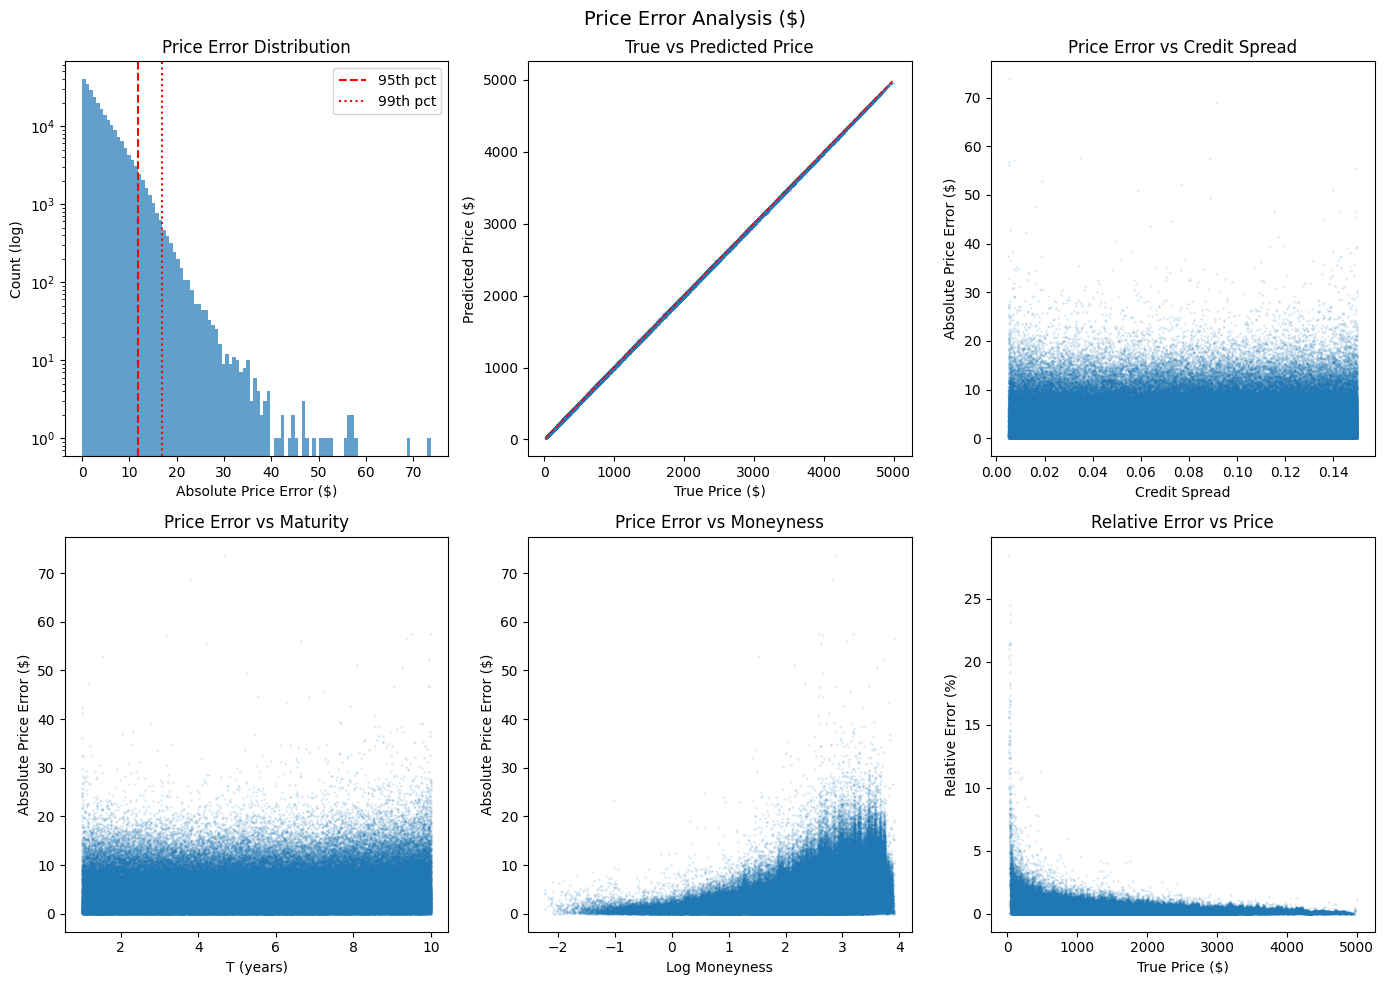

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# 1. Error distribution (log scale)
axes[0, 0].hist(analysis["price_err"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Absolute Price Error ($)")
axes[0, 0].set_ylabel("Count (log)")
axes[0, 0].set_title("Price Error Distribution")
axes[0, 0].axvline(analysis["price_err"].quantile(0.95), color="r", ls="--", label="95th pct")
axes[0, 0].axvline(analysis["price_err"].quantile(0.99), color="r", ls=":", label="99th pct")
axes[0, 0].legend()

# 2. True vs Predicted scatter
axes[0, 1].scatter(analysis["price_true"], analysis["price_pred"], s=1, alpha=0.1)
lims = [analysis["price_true"].min(), analysis["price_true"].max()]
axes[0, 1].plot(lims, lims, "r--", lw=1)
axes[0, 1].set_xlabel("True Price ($)")
axes[0, 1].set_ylabel("Predicted Price ($)")
axes[0, 1].set_title("True vs Predicted Price")

# 3. Error vs maturity
axes[1, 0].scatter(analysis["maturity_years"], analysis["price_err"], s=1, alpha=0.1)
axes[1, 0].set_xlabel("T (years)")
axes[1, 0].set_ylabel("Absolute Price Error ($)")
axes[1, 0].set_title("Price Error vs Maturity")

# 4. Error vs moneyness
axes[1, 1].scatter(analysis["log_moneyness"], analysis["price_err"], s=1, alpha=0.1)
axes[1, 1].set_xlabel("Log Moneyness")
axes[1, 1].set_ylabel("Absolute Price Error ($)")
axes[1, 1].set_title("Price Error vs Moneyness")

# 5. Error vs credit spread
axes[0, 2].scatter(analysis["credit_spread"], analysis["price_err"], s=1, alpha=0.1)
axes[0, 2].set_xlabel("Credit Spread")
axes[0, 2].set_ylabel("Absolute Price Error ($)")
axes[0, 2].set_title("Price Error vs Credit Spread")

# 6. Relative error (%) vs price
pct_err = analysis["price_err"] / analysis["price_true"] * 100
axes[1, 2].scatter(analysis["price_true"], pct_err, s=1, alpha=0.1)
axes[1, 2].set_xlabel("True Price ($)")
axes[1, 2].set_ylabel("Relative Error (%)")
axes[1, 2].set_title("Relative Error vs Price")

plt.suptitle("Price Error Analysis ($)", fontsize=14)
plt.tight_layout()
plt.show()

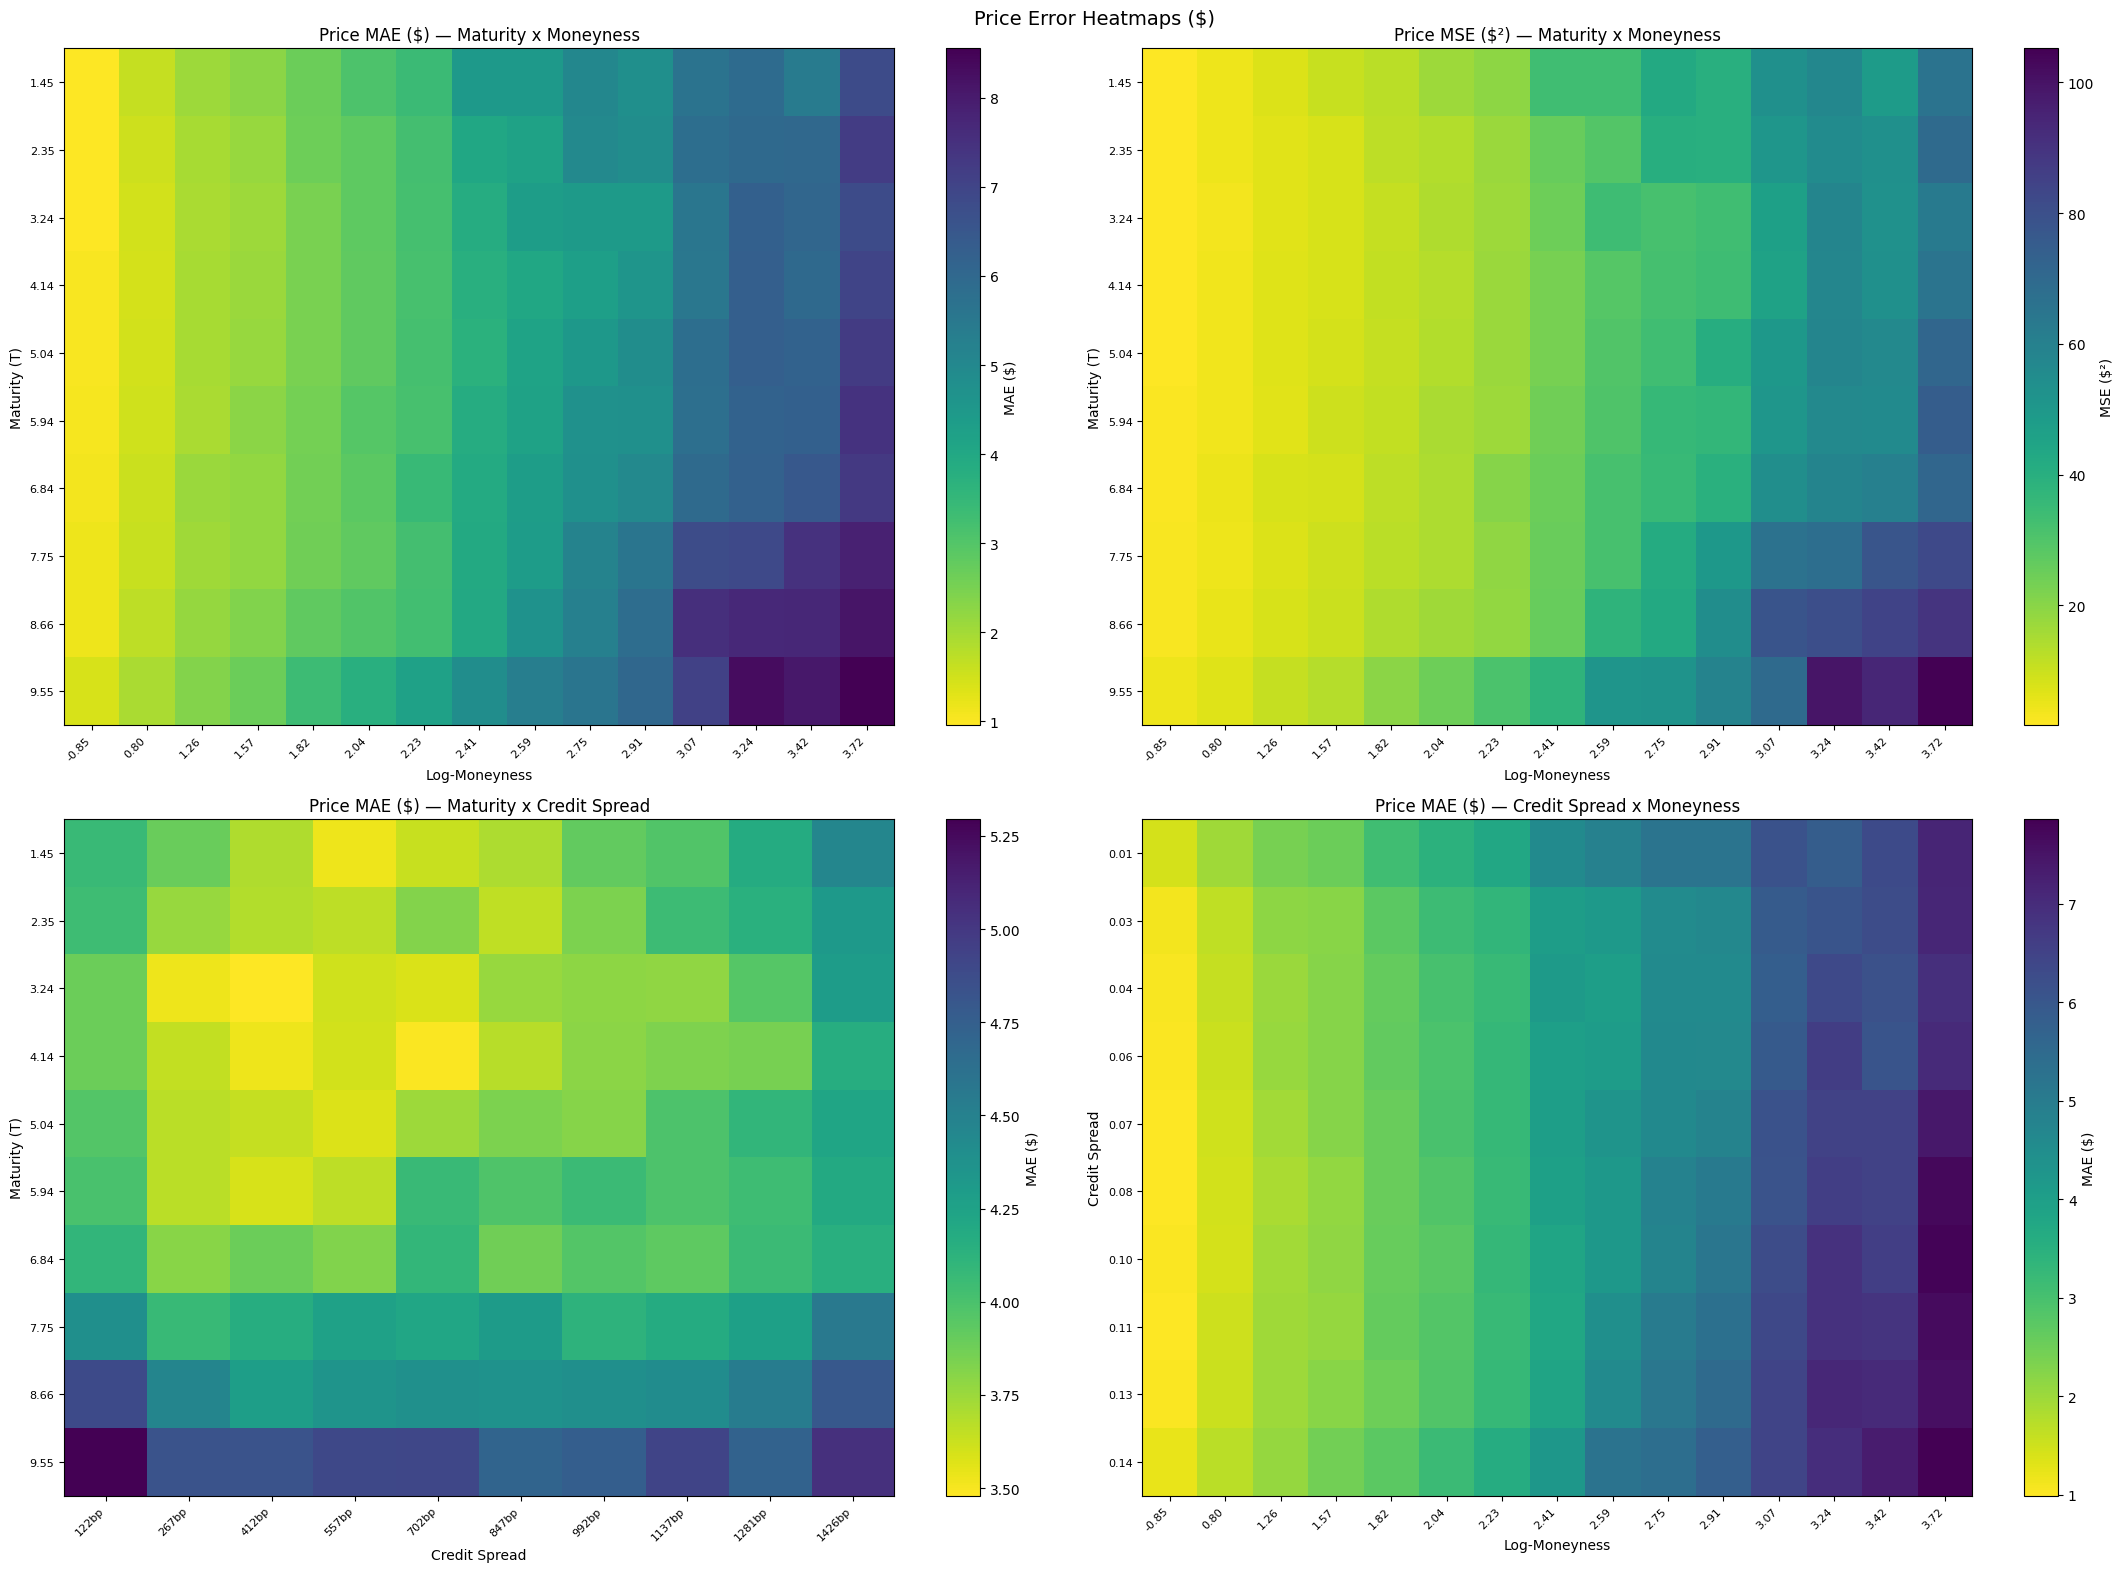

In [20]:
moneyness = analysis["log_moneyness"].values
maturity = analysis["maturity_years"].values
credit = analysis["credit_spread"].values
err_abs = analysis["price_err"].values
err_sq = err_abs ** 2

n_m, n_t, n_c = 15, 10, 10
m_edges = np.percentile(moneyness, np.linspace(0, 100, n_m + 1))
t_edges = np.percentile(maturity, np.linspace(0, 100, n_t + 1))
c_edges = np.percentile(credit, np.linspace(0, 100, n_c + 1))

m_idx = np.clip(np.digitize(moneyness, m_edges[1:-1]), 0, n_m - 1)
t_idx = np.clip(np.digitize(maturity, t_edges[1:-1]), 0, n_t - 1)
c_idx = np.clip(np.digitize(credit, c_edges[1:-1]), 0, n_c - 1)

def build_grid(row_idx, col_idx, n_row, n_col, vals):
    grid = np.full((n_row, n_col), np.nan)
    for ri in range(n_row):
        for ci in range(n_col):
            mask = (row_idx == ri) & (col_idx == ci)
            if mask.sum() > 0:
                grid[ri, ci] = vals[mask].mean()
    return grid

grid_mae_mm = build_grid(t_idx, m_idx, n_t, n_m, err_abs)
grid_mse_mm = build_grid(t_idx, m_idx, n_t, n_m, err_sq)
grid_mae_mc = build_grid(t_idx, c_idx, n_t, n_c, err_abs)
grid_mae_cm = build_grid(c_idx, m_idx, n_c, n_m, err_abs)

m_mids = 0.5 * (m_edges[:-1] + m_edges[1:])
t_mids = 0.5 * (t_edges[:-1] + t_edges[1:])
c_mids = 0.5 * (c_edges[:-1] + c_edges[1:])

fig, axes = plt.subplots(2, 2, figsize=(22, 16))

configs = [
    (axes[0, 0], grid_mae_mm, "Price MAE ($) \u2014 Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", "MAE ($)", n_m, n_t, "moneyness"),
    (axes[0, 1], grid_mse_mm, "Price MSE ($\u00b2) \u2014 Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", "MSE ($\u00b2)", n_m, n_t, "moneyness"),
    (axes[1, 0], grid_mae_mc, "Price MAE ($) \u2014 Maturity x Credit Spread",
     c_mids, t_mids, "Credit Spread", "Maturity (T)", "MAE ($)", n_c, n_t, "credit"),
    (axes[1, 1], grid_mae_cm, "Price MAE ($) \u2014 Credit Spread x Moneyness",
     m_mids, c_mids, "Log-Moneyness", "Credit Spread", "MAE ($)", n_m, n_c, "moneyness"),
]

for ax, grid, title, x_mids, y_mids, xlabel, ylabel, cbar_label, nx, ny, xtype in configs:
    im = ax.imshow(grid, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(nx))
    if xtype == "credit":
        ax.set_xticklabels([f"{int(v*10000)}bp" for v in x_mids], rotation=45, ha="right", fontsize=8)
    else:
        ax.set_xticklabels([f"{v:.2f}" for v in x_mids], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(ny))
    ax.set_yticklabels([f"{v:.2f}" for v in y_mids], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=cbar_label)

plt.suptitle("Price Error Heatmaps ($)", fontsize=14)
plt.tight_layout()
plt.show()

## Save Models

In [21]:
import os

save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

best_pricer.save(os.path.join(save_dir, f"moe_{M}x{N}_var_bw{BEST_BW}.pt"))

print(f"Saved best MoE to {save_dir}/moe_{M}x{N}_var_bw{BEST_BW}.pt")

Saved best MoE to ../models/moe_2x2_var_bw2.0.pt
